<a href="https://colab.research.google.com/github/WahyuKhairi06/BigData_2311531009_Wahyu-Khairi/blob/main/TB%20Praktikum/Tugas_Akhir_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==============================
# 1. IMPORT LIBRARY
# ==============================

In [239]:
!pip install imbalanced-learn

In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Wajib pakai Pipeline dari imblearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# ==============================
# 2. LOAD DATASET
# ==============================

In [241]:
url = "https://raw.githubusercontent.com/WahyuKhairi06/BigData_2311531009_Wahyu-Khairi/refs/heads/main/TB%20Praktikum/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(url)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

In [242]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [243]:
print("Statistik Deskriptif:\n", df.describe())

Statistik Deskriptif:
                  id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.09

/tmp/ipython-input-1742189089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


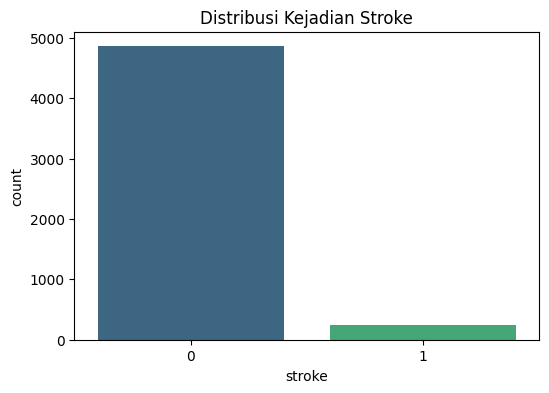

In [244]:
# Visualisasi 1: Distribusi Target (Stroke vs No Stroke)
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribusi Kejadian Stroke')
plt.show()

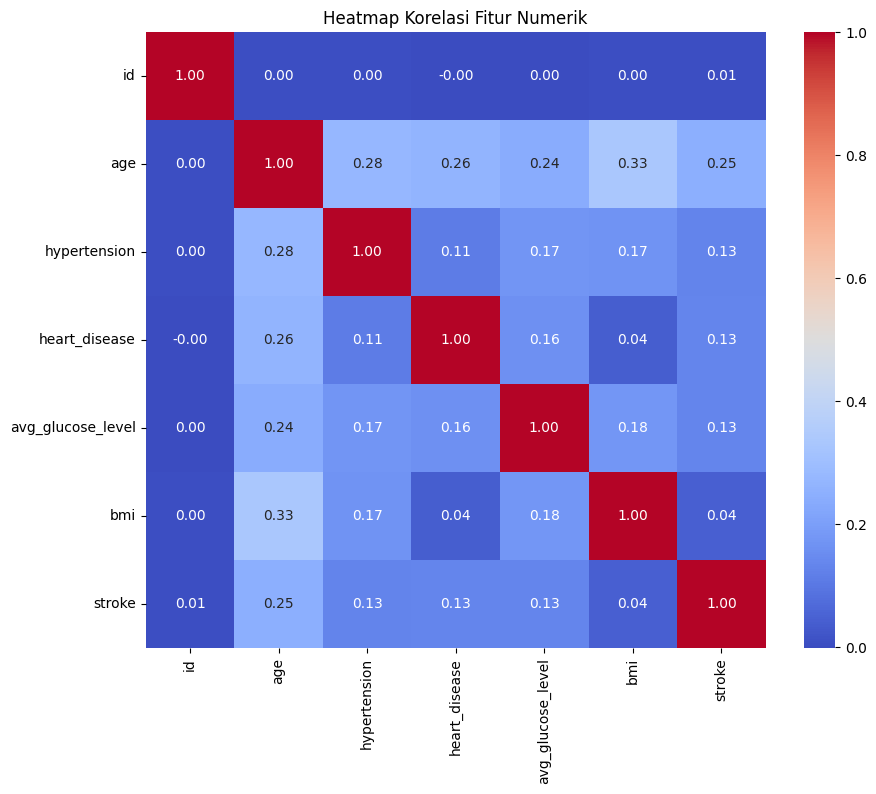

In [245]:
# Visualisasi 2: Korelasi Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

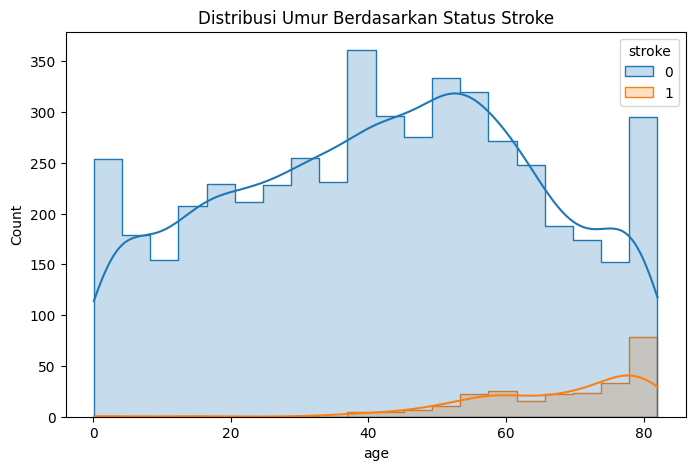

In [246]:
# Visualisasi 3: Distribusi Umur berdasarkan Stroke
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='stroke', kde=True, element="step")
plt.title('Distribusi Umur Berdasarkan Status Stroke')
plt.show()

# ==========================================
# 4. DATA PREPROCESSING
# ==========================================

In [247]:
# Cleaning [cite: 1]
df = df.drop(columns=['id'])
df = df[df['gender'] != 'Other']

# Penanganan Outliers (Capping BMI)
# Menghapus data BMI yang tidak masuk akal (di atas 60)
df = df[df['bmi'] < 60]

# Split Fitur & Target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Definisi Kolom [cite: 1]
numerical_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Pipeline Preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# ==========================================
# 5. MODELING & TUNING (2 ALGORITMA)
# ==========================================

In [248]:
#split train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [249]:
# Model 1: Logistic Regression
pipe_logreg = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# Model 2: Random Forest
pipe_rf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Hyperparameter Tuning untuk Model Terbaik (Logistic Regression)
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear']
}
grid_search = GridSearchCV(pipe_logreg, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

# Fit Random Forest (Default)
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

# ==========================================
# 6. EVALUASI & TABEL PERBANDINGAN
# ==========================================

In [250]:
models = {
    'Logistic Regression (Tuned)': grid_search.best_estimator_,
    'Random Forest (Default)': pipe_rf
}

comparison_data = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    })

df_comparison = pd.DataFrame(comparison_data)
print("\nTabel Perbandingan Evaluasi:\n", df_comparison)


Tabel Perbandingan Evaluasi:
                          Model  Accuracy  F1-Score   ROC-AUC
0  Logistic Regression (Tuned)  0.743616  0.213166  0.835214
1      Random Forest (Default)  0.956078  0.044444  0.779120


In [251]:
for name, model in models.items():
    print(f"\nClassification Report for {name}:")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))


Classification Report for Logistic Regression (Tuned):
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       937
           1       0.12      0.81      0.21        42

    accuracy                           0.74       979
   macro avg       0.56      0.78      0.53       979
weighted avg       0.95      0.74      0.82       979


Classification Report for Random Forest (Default):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       937
           1       0.33      0.02      0.04        42

    accuracy                           0.96       979
   macro avg       0.65      0.51      0.51       979
weighted avg       0.93      0.96      0.94       979



# ==========================================
# 7. SIMPAN MODEL TERBAIK
# ==========================================

In [252]:
best_model = grid_search.best_estimator_ # Berdasarkan F1-Score biasanya lebih stabil untuk data imbalanced
joblib.dump(best_model, "stroke_model.joblib")
print("\nModel terbaik berhasil disimpan!")


Model terbaik berhasil disimpan!
